# Oscar — checking my logistic regression against Yeh & Lien (2009)

3 Oct 2026. Rough working.

**Why.** My first logistic regression (`04-logistic`, first draft written with
Claude) used all 23 columns and scored AUC 0.72. That is the same set-up as the
main experiment in the paper that published this dataset:

> Yeh, I-C. & Lien, C-H. (2009). The comparisons of data mining techniques for
> the predictive accuracy of probability of default of credit card clients.
> *Expert Systems with Applications* 36(2), 2473–2480.
> https://doi.org/10.1016/j.eswa.2007.12.020

So this notebook reproduces their logistic-regression results and checks them,
using what lecture 01.2 (*Introduction to Classification*) and its R demo say a
classifier should be judged on.

**Plan:**

0. Load the cleaned data; split into train / calibration / test *(this step)*
1. Fit the paper's model: logistic regression on all 23 columns, no penalty
2. Their Table 1: error rate and area ratio
3. Their Fig. 3: lift chart
4. Precision–recall curve (lecture 01.2)
5. Are the scores probabilities? Their Sorting Smoothing Method vs a calibration curve
6. What matched, what didn't, and why

Several steps use material from another unit I've taken, *Statistical Machine Learning*
(MATH30028). Where they do, a short **"Link to MATH30028"** note says which section.
Reference: Maullin, T. (2026). *MATH30028 Statistical Machine Learning, Part I*, lecture notes, University of Bristol.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().parent
taiwan = pd.read_csv(ROOT / "data" / "processed" / "taiwan-clean.csv", index_col="ID")
Y = "default payment next month"
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8984"   # same colours as 04 and 06

print(taiwan.shape)                      # expect (29995, 24): 23 columns + the label
print(f"default rate {taiwan[Y].mean():.3f}")

(29995, 24)
default rate 0.221


## Step 0 — three-way split

Yeh & Lien split their data into two groups, training and validation, but
don't say what sizes. Lecture 01.2 suggests **three**: train, calibration,
test. Each part has one job:

| Part | Share | Used for |
|---|---|---|
| **train** | 60% | fitting the model |
| **calibration** | 20% | checking whether the scores behave like probabilities (step 5), and any choices we make from that |
| **test** | 20% | the final scores, looked at once, so they aren't flattered by choices made on it |

`train_test_split` only makes two parts, so we call it twice: first take 20%
off as the test set, then split the remaining 80% into 60% and 20% of the
whole (a quarter of 80% is 20%). `stratify` keeps the 22% default rate the same
in every part. `random_state=0` makes the split identical on every run.

> **Link to MATH30028 (SML).** §4.5 splits data into **train / validation / test** for the same reason as here: if
the test set is used to choose between models, it stops being "unseen" (their Fig.
4.3). Our *calibration* set plays the role of their *validation* set. Their rule of
thumb is 2/1/1 (50/25/25); we use 60/20/20 because 30,000 rows leave plenty for each
part.

In [2]:
X = taiwan.drop(columns=Y)
y = taiwan[Y]

X_rest, X_test, y_rest, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=0)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=0)

pd.DataFrame({
    "rows": [len(y_train), len(y_cal), len(y_test)],
    "share": np.round([len(y_train) / len(y), len(y_cal) / len(y), len(y_test) / len(y)], 3),
    "default rate": np.round([y_train.mean(), y_cal.mean(), y_test.mean()], 3),
}, index=["train", "calibration", "test"])

,rows,share,default rate
train,17997,0.6,0.221
calibration,5999,0.2,0.221
test,5999,0.2,0.221


## Step 1 — the paper's model: logistic regression, no penalty

Yeh & Lien fit a logistic regression on all 23 columns (X1–X23) and don't
mention a penalty. The R demo for lecture 01.2 uses `glm(..., family = binomial)`,
which has none. My first draft in `04` used scikit-learn's default, which does
add one: `C=1.0` puts a small cost on large weights (L2, "ridge"), pulling them
slightly towards 0.

To match the paper and the demo we turn the penalty off. In scikit-learn the
penalty's strength is `1 / C`, so **`C=np.inf`** means a penalty of zero.
(Older code writes `penalty=None`; scikit-learn 1.8 deprecated that in favour of
`C=np.inf`.)

We fit both versions on the **train** set and compare them on the
**calibration** set. The test set stays untouched.

`StandardScaler` is kept in both. Without a penalty, scaling doesn't change
the predictions, only the units of the weights, but it helps the fitting
algorithm converge and makes the weights comparable (change in log-odds per
1 SD), as in `04`.

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

paper = make_pipeline(StandardScaler(), LogisticRegression(C=np.inf, max_iter=5000))  # no penalty
draft = make_pipeline(StandardScaler(), LogisticRegression(C=1.0,    max_iter=5000))  # as in 04
paper.fit(X_train, y_train)
draft.fit(X_train, y_train)

# Predicted probability of default for each calibration-set customer.
p_cal_paper = paper.predict_proba(X_cal)[:, 1]
p_cal_draft = draft.predict_proba(X_cal)[:, 1]
gap = np.abs(p_cal_paper - p_cal_draft)

print(f"calibration AUC   no penalty {roc_auc_score(y_cal, p_cal_paper):.4f}"
      f"   C=1 {roc_auc_score(y_cal, p_cal_draft):.4f}")
print(f"difference in predicted probability   largest {gap.max():.4f}   average {gap.mean():.5f}")

calibration AUC   no penalty 0.7263   C=1 0.7263
difference in predicted probability   largest 0.0046   average 0.00011


In [4]:
# The weights side by side, largest change first.
coefs = pd.DataFrame({"no penalty": paper[-1].coef_[0], "C=1": draft[-1].coef_[0]}, index=X.columns)
coefs["change"] = coefs["no penalty"] - coefs["C=1"]
coefs.sort_values("change", key=abs, ascending=False).round(3).head(6)

,no penalty,C=1,change
BILL_AMT2,0.271,0.262,0.009
BILL_AMT1,-0.410,-0.403,-0.008
PAY_AMT1,-0.264,-0.261,-0.002
BILL_AMT4,-0.054,-0.052,-0.002
BILL_AMT6,0.037,0.036,0.001
PAY_AMT2,-0.118,-0.118,0.001


### Notes on step 1

* **The penalty makes no practical difference here.** Calibration AUC is 0.7263
  for both. Predicted probabilities differ by 0.0001 on average and by under
  0.005 at most. With 18,000 training rows and only 23 weights, the data
  outweighs the small `C=1` penalty. So my AI-drafted `04` was, in effect,
  already the paper's model. From here on we use `paper` (no penalty).
* **The weights that moved most are the bill columns** (`BILL_AMT1`,
  `BILL_AMT2`). These are the columns that overlap most (correlations 0.73–0.91
  in `03-predictors`), so the data pins them down least and the penalty has
  the most room to nudge them. `BILL_AMT1` is negative and `BILL_AMT2` positive,
  the same sign-flipping seen in `04`: read their combined effect, not each one.
* **AUC 0.726** on the calibration set, against 0.720 on `04`'s test set. The
  data (cleaned, 29,995 rows) and the split are different, so a small
  difference is expected.
* Also worth commenting on how the package update required a change in argument - was something covering this in one of the portfolio discussions

> **Link to MATH30028 (SML).** * **Logistic regression is a GLM** (§2.3.8, Example 3): a Bernoulli outcome with the
  logit link, log(p/(1−p)) = xᵀβ, fitted by maximum likelihood with a numerical
  method, as there's no closed form. scikit-learn's `lbfgs` is one such method.
* **The `C=1` penalty is ridge** (§2.2.3) applied to the logistic likelihood instead
  of the RSS. Its strength is set by 1/C, so `C=np.inf` is λ = 0, the unpenalised fit.
  Ridge's bias only buys a useful drop in variance when the data pin β down poorly.
  With 18,000 rows and 23 weights they don't, hence no difference here.
* **The bill weights flip sign because of multicollinearity** (§2.1.3). When
  covariates are near-copies of each other, β isn't pinned down: weight can move
  between them with almost no change in fit. Only their combined effect is
  interpretable. Ridge (§2.2.3) or summary columns are the fixes, as noted in `04`.
* **At threshold 0.5 the decision boundary is a hyperplane** (§3.2.4):
  p ≥ 0.5 ⇔ α + xᵀβ ≥ 0.

## Step 2 — the paper's Table 1: error rate and area ratio

Yeh & Lien score each method in two ways, on training and validation data.
Their validation data plays the role of our **test** set, so this is the step
where we look at it.

**Error rate** = share of customers put in the wrong class. We use a threshold
of 0.5 (predict "default" if p > 0.5); the paper doesn't state one, and 0.5 is
the usual default, as in the R demo.

**Area ratio** comes from the **lift chart** (also called a gains chart; step 3
draws it). Sort customers from highest to lowest predicted risk. Then plot the
share of all customers checked so far (x) against the share of all defaulters
caught so far (y). Three curves:

* **baseline**: random order, so the curve is the diagonal y = x;
* **best possible**: every defaulter comes first, so it rises at the steepest
  possible rate until all are caught;
* **model**: our sort order.

$$\text{area ratio} = \frac{\text{area between model and baseline}}
{\text{area between best possible and baseline}}$$

0 means no better than random, 1 means perfect. In credit scoring the same
number is called the **accuracy ratio** or **Gini coefficient**, and it always
equals **2 × AUC − 1** (Engelmann, Hayden & Tasche, 2003). We compute it from
the curve directly, as the paper does, and check it against the AUC.

Here the areas are measured with the trapezium rule (`np.trapezoid`). With
default rate $\pi$, the baseline encloses area 1/2, and the best curve
$\min(x/\pi, 1)$ encloses $1 - \pi/2$, so the gap between them is $(1 - \pi)/2$.

In [5]:
def gains_curve(y_true, p):
    """Lift (gains) chart points: share of customers checked (x) vs share of defaulters caught (y),
    checking customers from highest to lowest predicted risk."""
    y_sorted = np.asarray(y_true)[np.argsort(-p, kind="stable")]
    x = np.arange(len(y_sorted) + 1) / len(y_sorted)
    caught = np.concatenate([[0], np.cumsum(y_sorted)]) / y_sorted.sum()
    return x, caught

def area_ratio(y_true, p):
    """Yeh & Lien's area ratio: (model area - baseline area) / (best area - baseline area)."""
    x, caught = gains_curve(y_true, p)
    pi = np.mean(y_true)                       # default rate
    return (np.trapezoid(caught, x) - 0.5) / ((1 - pi) / 2)

def error_rate(y_true, p, threshold=0.5):
    return np.mean((p > threshold) != np.asarray(y_true))

p_train = paper.predict_proba(X_train)[:, 1]
p_test  = paper.predict_proba(X_test)[:, 1]      # the one look at the test set

table1 = pd.DataFrame({
    "error rate, training":   [0.20, error_rate(y_train, p_train)],
    "error rate, validation": [0.18, error_rate(y_test,  p_test)],
    "area ratio, training":   [0.41, area_ratio(y_train, p_train)],
    "area ratio, validation": [0.44, area_ratio(y_test,  p_test)],
}, index=["Yeh & Lien (2009), Table 1", "ours (validation = our test set)"])
display(table1.round(3))

# Check: the area ratio should equal 2 x AUC - 1.
print(f"test set: area ratio {area_ratio(y_test, p_test):.6f}   2*AUC-1 {2 * roc_auc_score(y_test, p_test) - 1:.6f}")
print(f"error rate of always saying 'no default': {y_test.mean():.3f}")

,"error rate, training","error rate, validation","area ratio, training","area ratio, validation"
"Yeh & Lien (2009), Table 1",0.20,0.180,0.410,0.440
ours (validation = our test set),0.19,0.188,0.455,0.425


test set: area ratio 0.424844   2*AUC-1 0.424844
error rate of always saying 'no default': 0.221


### How much is the gap just the split?

One test set is one random draw of customers. A different `random_state`
puts different customers in it and gives slightly different scores. To see how
big that wobble is, we repeat the paper's set-up 20 times: a two-way 80/20
split (train / validation, as they had), each with a different seed.

This is a separate check on the method, not the final score: across 20 splits
every customer ends up in some test set, so it doesn't replace the single
held-out result above.

In [6]:
repeats = []
for seed in range(20):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=0.20, stratify=y, random_state=seed)
    m = make_pipeline(StandardScaler(), LogisticRegression(C=np.inf, max_iter=5000)).fit(Xa, ya)
    pb = m.predict_proba(Xb)[:, 1]
    repeats.append({"seed": seed, "error rate": error_rate(yb, pb), "area ratio": area_ratio(yb, pb)})
repeats = pd.DataFrame(repeats).set_index("seed")

repeats.agg(["mean", "std", "min", "max"]).round(3)

,error rate,area ratio
mean,0.190,0.440
std,0.003,0.010
min,0.186,0.420
max,0.196,0.459


### Notes on step 2

* **We reproduce the paper's area ratio.** On our test set it is 0.425 against
  their 0.44. Over 20 different splits the average is **0.440**, exactly
  theirs, with a range of 0.42–0.46. So our single test set happens to fall
  at the low end, and the 0.015 gap is the luck of the split, not a different
  model.
* **The error rate is close but slightly higher**: 0.188 against 0.18, and even
  the best of our 20 splits gives 0.186. Their data may differ (the paper says
  25,000 rows; the UCI file has 30,000), or 0.18 may be rounded down. We can't
  tell from the paper.
* **Training area ratio**: ours is 0.455, a little above our test score, which
  is the usual pattern (a model fits the data it was trained on slightly
  better). Theirs is 0.41, *below* their validation score of 0.44. That's
  possible by chance with one split, but they don't comment on it.
* **The area ratio is the AUC in different units**: 0.424844 both ways, to six
  decimal places. So the paper's "area ratio" and the AUC used in lecture 01.2
  and in `04` always rank models the same way.
* **The error rate hides almost everything.** Saying "no default" to everyone
  gives an error rate of 0.221; the model only improves that to 0.188. The paper
  makes this point itself (error rate is "insensitive" when most customers
  don't default), and so does lecture 01.2 ("accuracy" is naive). That's why
  the next steps look at the whole ranking (lift chart) and at the
  probabilities themselves.

> **Link to MATH30028 (SML).** * **Error rate is the empirical 0–1 loss** (§3.1.3). Theorem 13 shows that predicting
  the most likely class, here p > 0.5 *if p is the true probability*, minimises the
  expected 0–1 loss. So 0.5 is the right threshold only if (a) every mistake costs the
  same and (b) the probabilities are calibrated. Step 4 questions (a); step 5
  questions (b).
* **The 20 splits aren't independent.** Any two training sets share most of their
  rows, the same issue §4.13.2 raises for K-fold cross-validation. So the spread
  (SD 0.010) describes how much *one* test set can vary. Dividing it by √20 would
  overstate how precisely we know the mean.

## Step 3 — the paper's Fig. 3: lift chart

The area ratio in step 2 is one number summarising this picture. Same axes as
the paper (counts, not shares): customers checked, riskiest first, against
defaulters caught, on our **test** set. The shading shows the ratio itself:

* **orange** = area between the model and random order (the top of the ratio),
* **orange + grey** = area between the best possible order and random (the bottom).

We also mark one point a lender could act on: how many defaulters we would
catch by checking only the riskiest 20% of customers.

> **For the final report:** show the paper's own lift chart for logistic
> regression (Yeh & Lien, 2009, **Fig. 3**, p. 2476) next to ours, so the
> reader can compare them directly. Credit it in the caption, e.g. *"Reproduced
> from Yeh & Lien (2009), Fig. 3."* Note when comparing: their x-axis counts
> their whole validation set (size not stated), ours counts our 5,999 test
> customers, so compare the **shape** and the area ratio, not the raw counts.

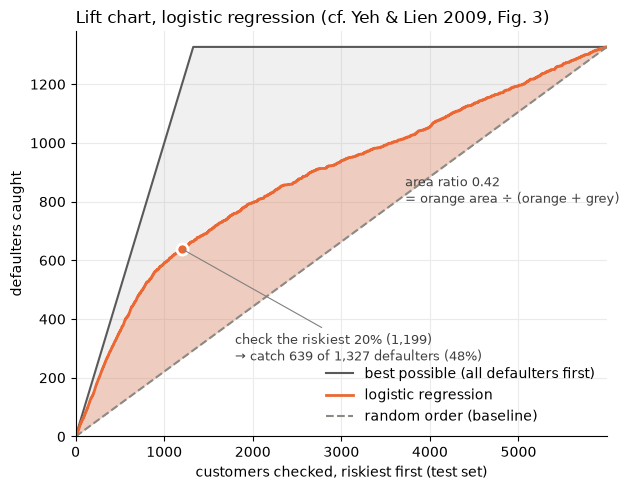

In [7]:
x, caught = gains_curve(y_test, p_test)
n, n_def = len(y_test), int(y_test.sum())
pi = n_def / n
checked, found = x * n, caught * n_def            # shares -> counts, as on the paper's axes
best = np.minimum(checked, n_def)                 # every defaulter first, then flat
k20 = int(0.2 * n)                                # the riskiest 20% of customers

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.fill_between(checked, checked * pi, best, color=GREY, alpha=0.12, linewidth=0)
ax.fill_between(checked, checked * pi, found, color=ORANGE, alpha=0.25, linewidth=0)
ax.plot(checked, best, color="0.35", linewidth=1.5, label="best possible (all defaulters first)")
ax.plot(checked, found, color=ORANGE, linewidth=2, label="logistic regression")
ax.plot(checked, checked * pi, color=GREY, linestyle="--", linewidth=1.5, label="random order (baseline)")

ax.plot(k20, found[k20], "o", color=ORANGE, markersize=8, markeredgecolor="white", markeredgewidth=2)
ax.annotate(f"check the riskiest 20% ({k20:,})\n→ catch {found[k20]:,.0f} of {n_def:,} defaulters ({caught[k20]:.0%})",
            xy=(k20, found[k20]), xytext=(k20 + 600, found[k20] - 380), fontsize=9, color="0.25",
            arrowprops=dict(arrowstyle="-", color="0.5", linewidth=0.8))
ax.text(n * 0.62, n_def * 0.60, f"area ratio {area_ratio(y_test, p_test):.2f}\n= orange area ÷ (orange + grey)",
        fontsize=9, color="0.25")

ax.set_xlim(0, n); ax.set_ylim(0, n_def * 1.04)
ax.set_xlabel("customers checked, riskiest first (test set)")
ax.set_ylabel("defaulters caught")
ax.set_title("Lift chart, logistic regression (cf. Yeh & Lien 2009, Fig. 3)", loc="left")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="0.92"); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### The same ranking, the way the lecture 01.2 R demo draws it

The R demo for lecture 01.2 plots each test case's **prediction score against
its rank order**, coloured by the true class. Copied directly, that doesn't
work here: sorting by score puts every point on one curve, so the defaulters
just sit on top of everyone else. So we split it in two:

* **top**: the score curve, from riskiest to safest customer;
* **bottom**: one thin orange line at the rank of each customer who actually
  defaulted. Dense on the left means the model ranks defaulters early.

We also mark where the score crosses 0.5, the threshold behind the error rate
in step 2.

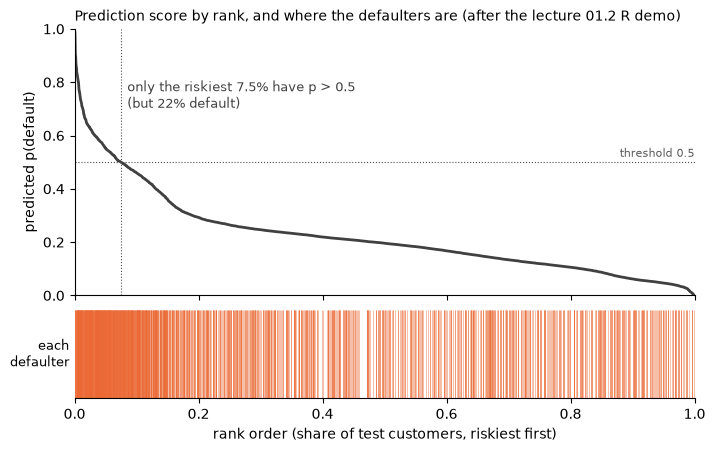

In [8]:
order = np.argsort(-p_test, kind="stable")
rank = np.arange(1, n + 1) / n                    # near 0 = riskiest, 1 = safest
p_sorted, y_sorted = p_test[order], np.asarray(y_test)[order]
flagged = np.mean(p_test > 0.5)                   # share of customers above the threshold

fig, (top, strip) = plt.subplots(2, 1, figsize=(8, 4.8), sharex=True,
                                 gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})
top.plot(rank, p_sorted, color="0.25", linewidth=2)
top.axhline(0.5, color="0.3", linewidth=0.8, linestyle=":")
top.axvline(flagged, color="0.3", linewidth=0.8, linestyle=":")
top.text(flagged + 0.01, 0.75, f"only the riskiest {flagged:.1%} have p > 0.5\n(but {y_test.mean():.0%} default)",
         fontsize=9, color="0.25", va="center")
top.text(1.0, 0.51, "threshold 0.5", ha="right", va="bottom", fontsize=8, color="0.35")
top.set_ylim(0, 1)
top.set_ylabel("predicted p(default)")
top.set_title("Prediction score by rank, and where the defaulters are (after the lecture 01.2 R demo)",
              loc="left", fontsize=10)

# eventplot draws one short vertical line per value: here, the rank of each defaulter.
strip.eventplot(rank[y_sorted == 1], colors=ORANGE, linewidths=0.6, alpha=0.5, lineoffsets=0.5, linelengths=1)
strip.set_yticks([]); strip.set_ylim(0, 1)
strip.set_ylabel("each\ndefaulter", rotation=0, ha="right", va="center", fontsize=9)
strip.set_xlim(0, 1)
strip.set_xlabel("rank order (share of test customers, riskiest first)")
for a in (top, strip):
    a.spines[["top", "right"]].set_visible(False)
strip.spines["left"].set_visible(False)
plt.show()

### Notes on step 3

* **The model ranks well at the top, then fades.** Checking the riskiest 20%
  of customers catches 48% of defaulters (639 of 1,327), against 20% for random
  order. The riskiest 10% alone catch 31%, and 69% of that group default.
  Past the top 40% the curve rises steadily but more slowly: the remaining 60%
  of customers still default at 13%, so a third of all defaulters (35%) are
  spread through the part of the ranking the model calls "safe". The strip
  shows the same thing: solid orange on the left, then a thinner, fairly even
  scatter.
* **The 0.5 threshold uses only the very top of the ranking.** Only 7.5% of
  customers (450) score above 0.5, although 22% default. Of those 450, 72% do
  default, but they are only 25% of all defaulters (326 of 1,327). That is why
  the error rate in step 2 barely beat "no default for everyone": at 0.5 the
  model hardly ever says "default". A lender who wanted to catch more would
  choose a lower threshold. Step 4 (precision and recall) shows that trade-off.
* **Why the scores sit so low.** Most customers get p between 0.1 and 0.3, even
  many who default. Whether those numbers are *right* as probabilities, e.g.
  whether 20% of people given p = 0.2 really default, is a separate question
  from ranking. Step 5 asks it.
* **Modification of the R demo.** Its score-by-rank plot, coloured by class,
  hides the defaulters when there are 6,000 points on one curve. Splitting it
  into a score curve and a strip of defaulters' ranks shows the same
  information legibly.

## Step 4 — precision and recall (lecture 01.2)

The paper stops at error rate and area ratio. Lecture 01.2 adds the
**precision–recall curve**, which it says is the right view "when we care
specifically about positive cases" (Davis & Goadrich, 2006). Here the
positive cases are the defaulters, which is what a lender cares about.

For a given threshold (flag everyone with p above it):

* **recall** = share of all defaulters that we flag (the same as "defaulters
  caught" in the lift chart);
* **precision** = share of the flagged customers who really default.

Lowering the threshold flags more people: recall goes up, precision usually
goes down. The curve shows every threshold at once. Random guessing has
precision 0.22 at every recall (the default rate), so that's the baseline.
**Average precision** sums the curve up in one number, like AUC does for ROC.

**Choosing a threshold properly.** Step 3 showed that 0.5 flags only 7.5% of
customers. As a simple alternative we pick the threshold with the best
**F1 score** (a balance of precision and recall: $F_1 = 2PR/(P+R)$). We choose it
on the **calibration** set and only then score it on the test set, so the test
result isn't flattered by the choice. This is what the three-way split in
step 0 is for.

In [9]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Choose the threshold on the CALIBRATION set: the one with the highest F1.
#    precision_recall_curve tries every threshold; its last point (recall 0) has no threshold, so skip it.
prec_c, rec_c, thr_c = precision_recall_curve(y_cal, p_cal_paper)
f1_c = 2 * prec_c[:-1] * rec_c[:-1] / (prec_c[:-1] + rec_c[:-1])
t_star = thr_c[np.nanargmax(f1_c)]

# 2. Score both thresholds on the TEST set.
def scores_at(y_true, p, threshold):
    y_true = np.asarray(y_true)
    flag = p >= threshold
    precision = y_true[flag].mean()
    recall = y_true[flag].sum() / y_true.sum()
    return {"share flagged": flag.mean(), "precision": precision, "recall": recall,
            "F1": 2 * precision * recall / (precision + recall),
            "error rate": np.mean(flag != y_true)}

pd.DataFrame({"threshold 0.5": scores_at(y_test, p_test, 0.5),
              f"threshold {t_star:.2f} (from calibration set)": scores_at(y_test, p_test, t_star)}).T.round(3)

,share flagged,precision,recall,F1,error rate
threshold 0.5,0.075,0.724,0.246,0.367,0.188
threshold 0.31 (from calibration set),0.185,0.558,0.466,0.508,0.200


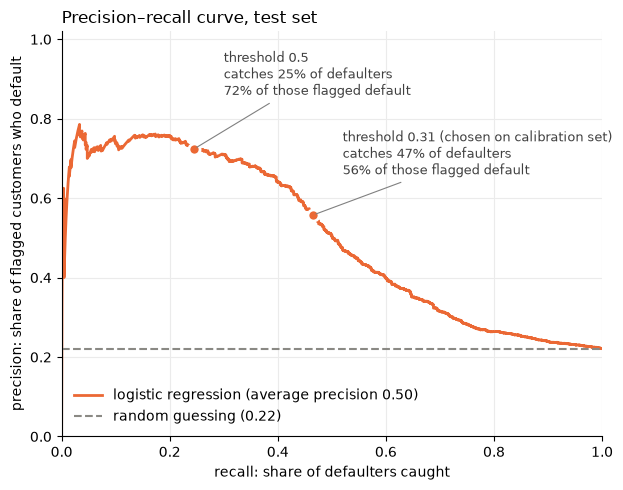

In [10]:
prec, rec, _ = precision_recall_curve(y_test, p_test)
ap = average_precision_score(y_test, p_test)

fig, ax = plt.subplots(figsize=(6.5, 5))
# Drop scikit-learn's added end point (precision 1, recall 0): it isn't a real threshold.
ax.plot(rec[:-1], prec[:-1], color=ORANGE, linewidth=2, label=f"logistic regression (average precision {ap:.2f})")
ax.axhline(y_test.mean(), color=GREY, linestyle="--", linewidth=1.5, label=f"random guessing ({y_test.mean():.2f})")

for th, name, text_at in [(0.5, "threshold 0.5", (0.30, 0.86)),
                          (t_star, f"threshold {t_star:.2f} (chosen on calibration set)", (0.52, 0.66))]:
    s = scores_at(y_test, p_test, th)
    ax.plot(s["recall"], s["precision"], "o", color=ORANGE, markersize=8, markeredgecolor="white", markeredgewidth=2)
    ax.annotate(f"{name}\ncatches {s['recall']:.0%} of defaulters\n{s['precision']:.0%} of those flagged default",
                xy=(s["recall"], s["precision"]), xytext=text_at, fontsize=9, color="0.25",
                arrowprops=dict(arrowstyle="-", color="0.5", linewidth=0.8))

ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_xlabel("recall: share of defaulters caught")
ax.set_ylabel("precision: share of flagged customers who default")
ax.set_title("Precision–recall curve, test set", loc="left")
ax.legend(frameon=False, loc="lower left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="0.92"); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

### Notes on step 4

* **Moving the threshold nearly doubles the defaulters caught.** The threshold
  chosen on the calibration set (0.31) catches 47% of defaulters on the test
  set, against 25% at 0.5. The price: precision falls from 72% to 56%, so more
  of the flagged customers are false alarms, and 18.5% of customers are flagged
  instead of 7.5%. F1 rises from 0.37 to 0.51.
* **…and the error rate gets *worse*** (0.188 → 0.200). By error rate, one of
  the paper's two measures, the more useful threshold looks like the poorer model. This is
  the clearest example of why the paper and lecture 01.2 both warn against error
  rate when most customers don't default: it counts a missed defaulter and a
  false alarm as equally bad, and there are far more non-defaulters to get wrong.
* **The model is the same at both thresholds.** Area ratio, AUC and average
  precision (0.50, against 0.22 for random guessing) don't change with the
  threshold. They judge the *ranking*. The threshold is a separate business
  decision, made after the model is fitted.
* **F1 is only one choice.** It weighs precision and recall equally. A lender
  would weigh them by cost: a missed defaulter usually costs far more than a
  false alarm. (German Credit comes with a cost matrix that puts this at 5 to 1.)
  Picking the threshold by expected cost is a natural next step for Sprint 1.

> **Link to MATH30028 (SML).** **Choosing the threshold by cost is Theorem 14** (§3.1.3, generalised loss). If a
missed defaulter costs c_FN and a false alarm costs c_FP, the expected loss is
smallest when we flag a customer whenever p · c_FN > (1 − p) · c_FP, that is,
p > c_FP / (c_FP + c_FN). With German Credit's 5-to-1 costs that threshold is
1/6 ≈ 0.17. This only works if p is a real probability, which is why step 5 (and
`08`) check and fix calibration.

## Step 5 — are the scores probabilities?

Steps 2–4 only judged the **ranking**: who comes first. Lecture 01.2 asks a
different question: "are these probabilities?" If the model says p = 0.2 for a
group of customers, do about 20% of them default? A model that does this is
**calibrated**. It matters to a lender, because expected losses and
provisions are worked out from the probabilities themselves, not just the order.

### The paper's answer: the Sorting Smoothing Method (SSM)

This is Yeh & Lien's new method. Sort customers by predicted p, from lowest to highest.
For customer $i$, estimate the "real" probability of default as the share of
defaulters among them and their $n$ neighbours on each side:

$$P_i = \frac{Y_{i-n} + \dots + Y_{i-1} + Y_i + Y_{i+1} + \dots + Y_{i+n}}{2n + 1},$$

where $Y = 1$ for a default and 0 otherwise. They use $n = 50$, so each estimate
averages 101 customers. This is a **moving average** of the outcomes along the
sorted list. In code, `np.convolve` with a window of 101 equal weights computes
it in one line. The first and last 50 customers have no full window, so we
leave them out (the paper doesn't say what it did there).

They then fit a straight line, real = A + B × predicted. A calibrated model
would give **B = 1, A = 0**, and they use R² to measure how close the points
lie to the line. For logistic regression, their Table 2 reports
**B = 1.233, A = −0.0523, R² = 0.794**.

### The standard answer: a calibration curve and the Brier score

* **`calibration_curve`** (scikit-learn) does the same job with groups instead
  of a moving window: split customers into 10 equal-size groups by predicted p,
  then plot each group's average prediction against its actual default rate.
  A calibrated model lies on the diagonal.
* **Brier score** = average of $(p - Y)^2$ over customers: 0 is perfect, lower
  is better. It rewards both good ranking and good calibration (a "proper
  scoring rule": Gneiting & Raftery, 2007). As a yardstick we compare it with
  predicting the training default rate (22%) for everyone.

As planned in step 0, this check is done on the **calibration** set. The test
set's numbers are shown alongside only for comparison.

In [11]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

def ssm(y_true, p, n=50):
    """Yeh & Lien's Sorting Smoothing Method: sort by p, then a moving average of the
    outcomes over 2n+1 customers. Returns (predicted p, estimated real p) for each
    customer with a full window."""
    order = np.argsort(p, kind="stable")                    # lowest p first
    p_sorted, y_sorted = p[order], np.asarray(y_true)[order]
    window = 2 * n + 1
    real = np.convolve(y_sorted, np.ones(window) / window, mode="valid")   # 'valid' = full windows only
    return p_sorted[n:len(p_sorted) - n], real

def ssm_line(y_true, p, n=50):
    """Fit real = A + B * predicted, as in the paper's Table 2."""
    pred, real = ssm(y_true, p, n)
    B, A = np.polyfit(pred, real, 1)                        # polyfit returns the slope first
    r2 = np.corrcoef(pred, real)[0, 1] ** 2
    return {"slope B": B, "intercept A": A, "R²": r2}

def brier(y_true, p):
    return {"Brier": brier_score_loss(y_true, p),
            "Brier, predict 22% for all": brier_score_loss(y_true, np.full(len(y_true), y_train.mean()))}

pd.DataFrame({
    "Yeh & Lien (2009), Table 2": {"slope B": 1.233, "intercept A": -0.0523, "R²": 0.794},
    "ours, calibration set":      {**ssm_line(y_cal, p_cal_paper),  **brier(y_cal, p_cal_paper)},
    "ours, test set":             {**ssm_line(y_test, p_test),      **brier(y_test, p_test)},
}).T.round(4)

,slope B,intercept A,R²,Brier,"Brier, predict 22% for all"
"Yeh & Lien (2009), Table 2",1.2330,-0.0523,0.7940,NaN,NaN
"ours, calibration set",1.1483,-0.0338,0.8382,0.1441,0.1723
"ours, test set",1.1190,-0.0280,0.8085,0.1457,0.1723


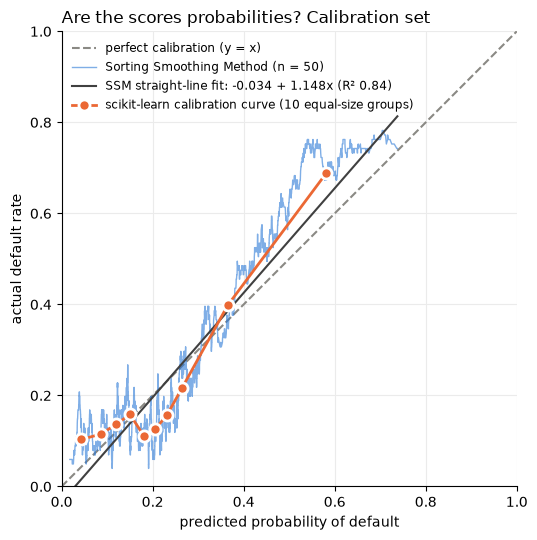

,average predicted p,actual default rate,actual - predicted
group (1 = lowest risk),,,
1,0.043,0.103,0.060
2,0.086,0.115,0.029
3,0.120,0.137,0.016
4,0.150,0.158,0.008
5,0.181,0.112,-0.069
6,0.206,0.127,-0.079
7,0.231,0.157,-0.075
8,0.265,0.217,-0.048
9,0.365,0.398,0.033


In [12]:
pred, real = ssm(y_cal, p_cal_paper)
line = ssm_line(y_cal, p_cal_paper)
frac, mean_p = calibration_curve(y_cal, p_cal_paper, n_bins=10, strategy="quantile")   # 10 equal-size groups

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot([0, 1], [0, 1], color=GREY, linestyle="--", linewidth=1.5, label="perfect calibration (y = x)")
ax.plot(pred, real, color=BLUE, linewidth=1, alpha=0.6, label="Sorting Smoothing Method (n = 50)")
xs = np.array([pred.min(), pred.max()])                    # draw the fitted line over the data only
ax.plot(xs, line["intercept A"] + line["slope B"] * xs, color="0.25", linewidth=1.5,
        label=f"SSM straight-line fit: {line['intercept A']:.3f} + {line['slope B']:.3f}x (R² {line['R²']:.2f})")
ax.plot(mean_p, frac, "o-", color=ORANGE, linewidth=2, markersize=8, markeredgecolor="white", markeredgewidth=2,
        label="scikit-learn calibration curve (10 equal-size groups)")

ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.set_xlabel("predicted probability of default")
ax.set_ylabel("actual default rate")
ax.set_title("Are the scores probabilities? Calibration set", loc="left")
ax.legend(frameon=False, loc="upper left", fontsize=8.5)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="0.92"); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# The ten groups as a table: where is the model too high, where too low?
pd.DataFrame({"average predicted p": mean_p, "actual default rate": frac,
              "actual - predicted": frac - mean_p}, index=pd.RangeIndex(1, 11, name="group (1 = lowest risk)")).round(3)

In [13]:
# Does the paper's R² depend on its choice of n? Same model, same data, different smoothing.
pd.DataFrame({f"n = {n}": ssm_line(y_cal, p_cal_paper, n) for n in [10, 25, 50, 100, 200]}).T.round(3)

,slope B,intercept A,R²
n = 10,1.122,-0.028,0.729
n = 25,1.131,-0.030,0.811
n = 50,1.148,-0.034,0.838
n = 100,1.158,-0.036,0.850
n = 200,1.157,-0.039,0.851


### Notes on step 5

* **We reproduce the paper's pattern.** Slope above 1 and intercept below 0 for
  logistic regression, as in their Table 2: B = 1.15 (theirs 1.23), A = −0.034
  (theirs −0.052), R² = 0.84 (theirs 0.79). Read literally, the line says the
  predictions are too bunched together: it crosses the diagonal at about
  p = 0.23, so below that the model predicts too much default, and above it too
  little.
* **But the calibration isn't a straight line, so the fitted line misleads.**
  The ten groups tell a different story at the low end:
  * groups 1–4 (p up to 0.15): actual default is **higher** than predicted. Group
    1 is predicted 4% and actually defaults at 10%. The fitted line says 1.5%
    there, which is the wrong way round;
  * groups 5–8 (p 0.18–0.27): actual is **lower** than predicted, by 5–8 points;
  * groups 9–10: actual is **higher** again; the top group is predicted 58% and
    defaults at 69%.

  So the miscalibration has an S shape. A single A and B can't describe it, and a
  high R² doesn't mean the line fits where it matters.
* **The ranking breaks in the middle.** Group 5 (predicted 18%) defaults *less*
  (11%) than group 4 (predicted 15%, actual 16%). Among low-to-middle scores, a
  higher score doesn't mean more risk. That fits step 3, where the lift curve
  flattens past the riskiest 40%. A likely cause is weakness 2 in `04`: the
  `PAY_*` codes (−2, −1, 0, 1, …) are used as plain numbers, which forces one
  straight-line effect onto categories that behave differently.
* **The paper's R² depends on its own choice of n.** Same model, same data: R²
  goes from 0.73 at n = 10 to 0.85 at n = 200, because wider windows average away
  more noise. Neighbouring points also share 100 of their 101 customers, so they
  aren't independent observations. R² here measures how smooth the curve is as
  much as how well calibrated the model is. The paper's conclusion that only the
  neural network "can accurately estimate the real probability of default" rests
  on this measure.
* **The Brier score has neither problem.** It is 0.144, against 0.172 for
  predicting 22% for everyone: a **Brier skill score** of 1 − 0.144/0.172 ≈ 0.16,
  so the model removes about 16% of the error of the no-information forecast. It
  needs no smoothing choice, and as a proper scoring rule it can't be improved by
  reporting anything other than your honest probabilities (Gneiting & Raftery, 2007).
* **For Sprint 1:** the calibration set can be used to *fix* the calibration, not
  just check it: refit the probabilities with Platt scaling or isotonic
  regression (scikit-learn's `CalibratedClassifierCV`), then judge the result on
  the test set. Treating the `PAY_*` codes as categories should help both the
  ranking and the calibration.

> **Link to MATH30028 (SML).** * **The Sorting Smoothing Method is a box-kernel smoother.** Each estimate averages the
  outcomes in a window of 101 customers. That's the "unit box" idea behind histograms
  and kernel density estimation (§4.14.5, Figs 4.10–4.11), with n playing the role of
  the **bandwidth**. As with any bandwidth, a wider window gives a smoother but more
  biased curve. That is why R² rises with n.
* **The 10-group calibration curve is histogram regression** (§2.3.3): a piecewise-
  constant fit of the outcome on p, with knots at the deciles.
* **The S-shaped miscalibration suggests the model is too rigid.** A plain linear
  logit can't bend. Basis functions (§2.3.2), such as one-hot `PAY_*` codes
  (piecewise constant) or log amounts, or a GAM (§2.3.9), would let it, which links
  back to the weaknesses listed in `04`.